In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import datetime as dt
import seaborn as sns
import numpy as np
from mlxtend.frequent_patterns import association_rules, apriori
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
import warnings
warnings.filterwarnings("ignore")

In [69]:
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:   
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [70]:
df = pd.read_csv("hm_analysis.csv")

In [ ]:
df.info() # date type이 바뀜

<class 'pandas.DataFrame'>
RangeIndex: 31648066 entries, 0 to 31648065
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   t_dat               str    
 1   customer_id         str    
 2   price               float64
 3   age                 int64  
 4   Active              int64  
 5   FN                  int64  
 6   club_member_status  str    
 7   age_group           str    
 8   article_id          int64  
 9   prod_name           str    
 10  product_group_name  str    
 11  section_name        str    
 12  garment_group_name  str    
dtypes: float64(1), int64(4), str(8)
memory usage: 7.4 GB


In [72]:
df['t_dat'] = pd.to_datetime(df['t_dat']) # 수정

## RFM 지표

In [73]:
# 1. RFM 지표 계산
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

# 2. 확인
print(rfm.head())

                                         customer_id  Recency  Frequency  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       18         10   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...       77         23   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...        8          7   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...      472          1   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...       42          6   

   Monetary  
0    382.90  
1   1535.14  
2    415.82  
3     35.98  
4    277.12  


#### 4분위수로 확인

In [74]:
quantiles = [0.25, 0.5, 0.75]

# 1. 각 지표별 경계값(Quantile) 계산
# .quantile() 함수를 사용하면 해당 백분율에 위치한 실제 값을 바로 찾아줍니다.
rfm_thresholds = rfm[['Recency', 'Frequency', 'Monetary']].quantile(quantiles)

# 2. 결과 출력
print("📊 RFM 지표별 4분위수 경계값")
print("-" * 45)
print(rfm_thresholds)

📊 RFM 지표별 4분위수 경계값
---------------------------------------------
      Recency  Frequency  Monetary
0.25     49.0        1.0     52.94
0.50    150.0        3.0    145.96
0.75    395.0        8.0    417.63


#### 5분위수로 확인

In [75]:
quantiles = [0.2, 0.4, 0.6, 0.8]

# 1. 각 지표별 경계값(Quantile) 계산
# .quantile() 함수를 사용하면 해당 백분율에 위치한 실제 값을 바로 찾아줍니다.
rfm_thresholds = rfm[['Recency', 'Frequency', 'Monetary']].quantile(quantiles)

# 2. 결과 출력
print("📊 RFM 지표별 5분위수 경계값")
print("-" * 45)
print(rfm_thresholds)

📊 RFM 지표별 5분위수 경계값
---------------------------------------------
     Recency  Frequency  Monetary
0.2     35.0        1.0    40.960
0.4     95.0        2.0    97.960
0.6    229.0        4.0   218.870
0.8    458.0       10.0   531.332


## RFM 분포 시각화

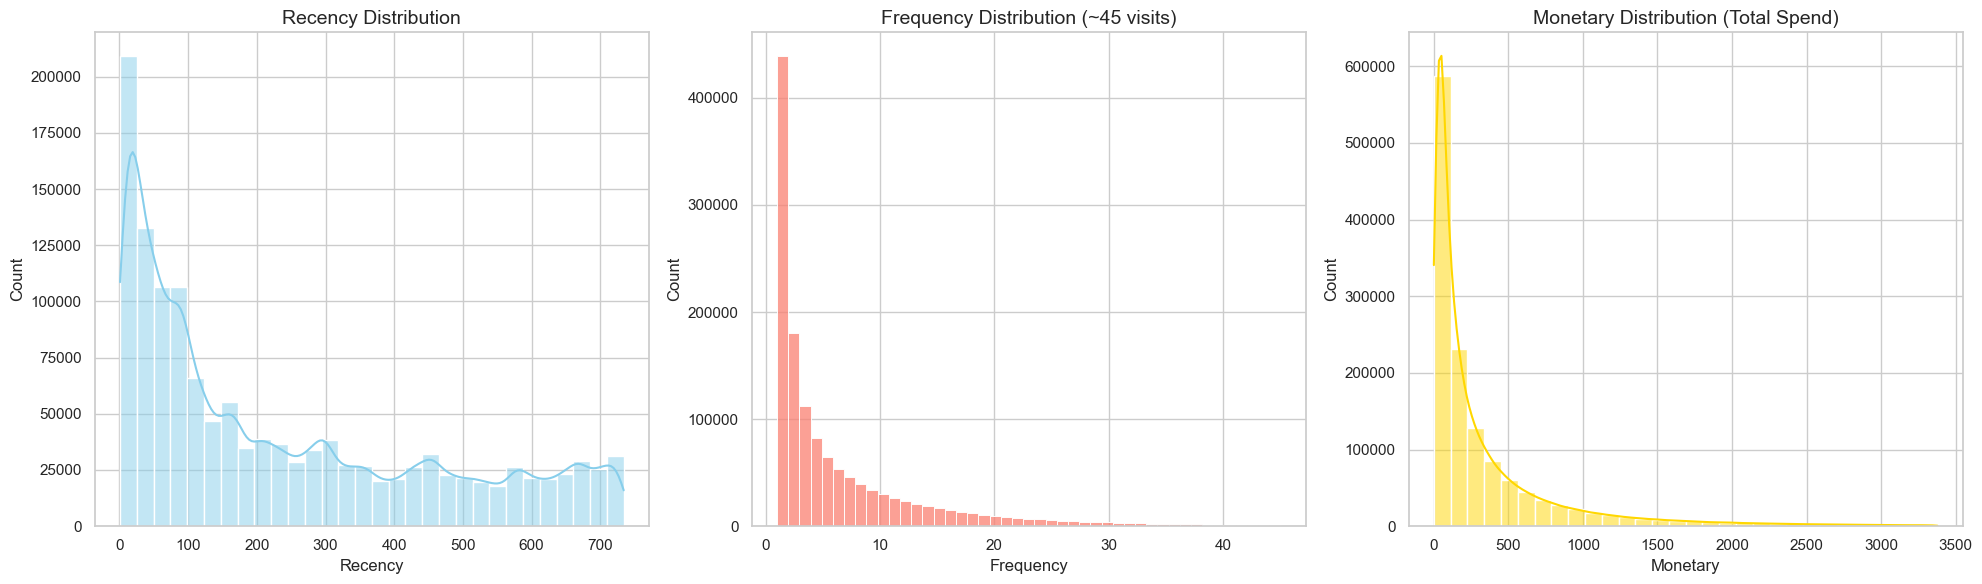

In [76]:
# 시각화 (이제 rfm 변수를 사용하여 히스토그램을 그립니다)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Recency
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution', fontsize=14)

# Frequency (상위 1% 제외하고 시각화하여 분포 파악 용이하게 설정)
f_limit = rfm['Frequency'].quantile(0.99)
sns.histplot(rfm[rfm['Frequency'] <= f_limit]['Frequency'], bins=int(f_limit), kde=False, ax=axes[1], color='salmon')
axes[1].set_title(f'Frequency Distribution (~{int(f_limit)} visits)', fontsize=14)

# Monetary (상위 1% 제외)
m_limit = rfm['Monetary'].quantile(0.99)
sns.histplot(rfm[rfm['Monetary'] <= m_limit]['Monetary'], bins=30, kde=True, ax=axes[2], color='gold')
axes[2].set_title(f'Monetary Distribution (Total Spend)', fontsize=14)

plt.tight_layout()
plt.show()

## 5분위수로 세그먼트 나누기

In [77]:
# 1. 각 지표별로 백분율 순위(Percentile Rank) 계산
# pct=True 옵션은 0(최하위) ~ 1(최상위) 사이의 값을 반환합니다.
rfm['R_pct'] = rfm['Recency'].rank(pct=True, ascending=False) # Recency는 작을수록 좋으므로 내림차순
rfm['F_pct'] = rfm['Frequency'].rank(pct=True, ascending=True)
rfm['M_pct'] = rfm['Monetary'].rank(pct=True, ascending=True)

# 2. 백분율을 기반으로 1~5점 부여
def get_score(pct):
    if pct >= 0.8: return 5
    elif pct >= 0.6: return 4
    elif pct >= 0.4: return 3
    elif pct >= 0.2: return 2
    else: return 1

rfm['R_Score'] = rfm['R_pct'].apply(get_score)
rfm['F_Score'] = rfm['F_pct'].apply(get_score)
rfm['M_Score'] = rfm['M_pct'].apply(get_score)

# 3. 통합 점수 계산 (백분율 자체를 합산하여 평균을 낼 수도 있습니다)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# 4. 세그먼트 분류 (백분율 기준 강화)
def get_segment_by_pct(row):
    # 상위 10% (R, F, M 백분율 평균이 0.9 이상인 진짜 VIP)
    avg_pct = (row['R_pct'] + row['F_pct'] + row['M_pct']) / 3
    
    if avg_pct >= 0.9:
        return '최상위 VVIP'
    elif row['RFM_Score'] >= 12:
        return '우수 고객'
    elif row['R_pct'] <= 0.2 and row['F_pct'] >= 0.6:
        return '이탈 위기 단골'
    elif row['M_pct'] >= 0.8 and row['R_pct'] <= 0.3:
        return '휴면 큰손'
    else:
        return '일반 고객'

rfm['Segment'] = rfm.apply(get_segment_by_pct, axis=1)

print(rfm['Segment'].value_counts(normalize=True) * 100) # 비중 확인(%)

Segment
일반 고객       68.554645
우수 고객       24.382705
최상위 VVIP     5.960773
이탈 위기 단골     0.640392
휴면 큰손        0.461486
Name: proportion, dtype: float64


## K-means

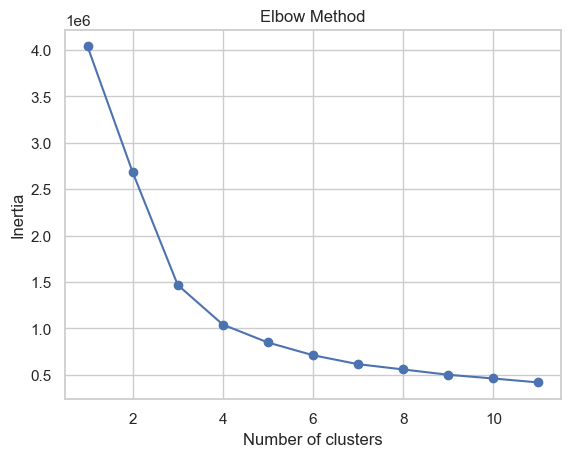

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 분석에 사용할 컬럼 추출
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

#몇 개의 그룹으로 나누는 게 가장 좋을지 결정해야 합니다. 
# 보통 Elbow Method라는 그래프를 그려서 꺾이는 지점을 찾습니다.
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 12), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [79]:
# 통계적 신뢰도 (중심극한정리)
# # Silhouette Score(실루엣 계수)
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. 무작위로 10,000개의 인덱스 추출 (130만 건 중 1만 건)
sample_size = 10000
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
rfm_scaled_sample = rfm_scaled[indices]

# 3. K=3일 때의 점수 계산
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# 4. K=4일 때의 점수 계산
kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

print(f"표본(1만건) 기준 K=3 실루엣 점수: {score3:.4f}")
print(f"표본(1만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(1만건) 기준 K=3 실루엣 점수: 0.5065
표본(1만건) 기준 K=4 실루엣 점수: 0.5129


In [80]:
# 1. 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '구매횟수(번)', 'Monetary': '총구매금액($)'})

# 3. 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    구매횟수(번)     총구매금액($)     고객수
Cluster                                            
2         26.196254  48.809950  3921.397695   25146
0         53.011222  19.719427  1137.029811  198458
3        125.074712   4.383024   215.267293  722524
1        534.993691   1.813285    99.653741  400392


In [81]:
# 2번(VIP) : 최근에도 왔고, 가장 자주, 많이 구매함. ZEP 라운지 우선 초대 및 한정판 드롭 타겟.
# 0번(잠재적 이탈 단골) :  꽤 자주 이용했었으나 최근 6개월간 방문 뜸함. 리워드 쿠폰으로 재방문 유도가 시급함.
# 3번 (신규 및 유망자) : 구매액은 적지만 최근 활동성이 좋음. 첫 구매 혜택이나 카테고리 확장 유도 필요.
# 1번 (휴먼 고객) :  1년 넘게 방문 안 함. 인원수가 가장 많음. 대규모 리타겟팅 광고나 수신동의 혜택 제안.

## Clouster3 타겟

In [82]:
# 1. Cluster 3 고객 아이디만 추출
c3_users = rfm[rfm['Cluster'] == 3]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c3_data = df[df['customer_id'].isin(c3_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("🛍️ Cluster 3가 가장 선호하는 카테고리 Top 10")
print(c3_data['garment_group_name'].value_counts().head(10))

print("\n👕 Cluster 3가 가장 많이 산 구체적 상품명 Top 10")
print(c3_data['prod_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c3_data['age'].mean()
print(f"\n👥 Cluster 3의 평균 나이: {avg_age:.1f}세")

🛍️ Cluster 3가 가장 선호하는 카테고리 Top 10
garment_group_name
Jersey Fancy         1617661
Jersey Basic         1109177
Under-, Nightwear    1043894
Swimwear              922998
Trousers              907135
Blouses               737428
Knitwear              692791
Dresses Ladies        607733
Accessories           525435
Trousers Denim        373817
Name: count, dtype: int64

👕 Cluster 3가 가장 많이 산 구체적 상품명 Top 10
prod_name
Jade HW Skinny Denim TRS       64426
Timeless Midrise Brief         53613
Luna skinny RW                 49762
Tilly (1)                      43117
Simple as That Triangle Top    34167
Cat Tee.                       33534
Tilda tank                     31126
Simple as that Cheeky Tanga    28476
Shake it in Balconette         28423
Skinny Ankle R.W Brooklyn      24998
Name: count, dtype: int64

👥 Cluster 3의 평균 나이: 35.2세


In [83]:
# 1. 만약 고객 ID가 들어있는 데이터프레임 이름이 'user_df'나 'customers'라면 그걸 넣으세요.
# 만약 기억이 안 난다면, 클러스터링 직전에 사용했던 변수를 확인해보세요.

customer_clusters = pd.DataFrame({
    'customer_id': df['customer_id'].unique(), # 원본 df에서 중복 없는 고객 ID만 가져오기
    'cluster': kmeans.labels_
})

# 2. 이제 다시 합치기(Merge)
df_final = df.merge(customer_clusters, on='customer_id', how='inner')

# 3. Cluster 3만 필터링
c3_df = df_final[df_final['cluster'] == 3]

print(f"성공! Cluster 3 데이터 {len(c3_df)}건 추출 완료.")

성공! Cluster 3 데이터 16980341건 추출 완료.


In [99]:
df_final.head()

,t_dat,customer_id,price,age,Active,FN,club_member_status,age_group,article_id,prod_name,product_group_name,section_name,garment_group_name,cluster
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,29.99,24,0,0,ACTIVE,20대,663713001,Atlanta Push Body Harlow,Underwear,Womens Lingerie,"Under-, Nightwear",3
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,17.99,24,0,0,ACTIVE,20대,541518023,Rae Push (Melbourne) 2p,Underwear,Womens Lingerie,"Under-, Nightwear",3
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,8.99,32,1,1,ACTIVE,30대,505221004,Inca Jumper,Garment Upper body,Divided Selected,Knitwear,0
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,9.99,32,1,1,ACTIVE,30대,685687003,W YODA KNIT OL OFFER,Garment Upper body,Womens Everyday Collection,Special Offers,0
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,9.99,32,1,1,ACTIVE,30대,685687004,W YODA KNIT OL OFFER,Garment Upper body,Womens Everyday Collection,Special Offers,0


## 연관분석

In [87]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. 분석할 Cluster 3의 Top 10 카테고리 리스트 정의
target_categories = [
    'Jersey Fancy', 'Jersey Basic', 'Under-, Nightwear', 'Swimwear',
    'Trousers', 'Blouses', 'Knitwear', 'Dresses Ladies', 
    'Accessories', 'Trousers Denim'
]

# 2. 데이터 필터링 (에러 방지를 위해 df_final 사용)
# 'cluster' 컬럼이 있는 df_final에서 3번 클러스터만 먼저 추출합니다.
c3_df = df_final[df_final['cluster'] == 3]

# 그 중 우리가 정한 10개 카테고리에 속하는 데이터만 남깁니다.
c3_cat_only = c3_df[c3_df['garment_group_name'].isin(target_categories)].copy()

# 3. 장바구니 만들기 (pivot_table 방식이 더 안정적일 수 있습니다)
# 고객별+날짜별로 어떤 카테고리를 샀는지 10개의 열로 펼칩니다.
basket_cat = (c3_cat_only.groupby(['customer_id', 't_dat', 'garment_group_name'])['garment_group_name']
              .count().unstack().fillna(0))

# 4. 데이터 이진화 (구매 여부 0/1)
# 1개 이상 샀으면 1, 아니면 0으로 변환하여 연관분석 규격에 맞춥니다.
basket_sets_cat = basket_cat.map(lambda x: 1 if x > 0 else 0)

# 5. 연관분석 실행
# 카테고리 데이터는 조합이 흔하므로 min_support를 0.01(1%)로 설정합니다.
frequent_itemsets = apriori(basket_sets_cat, min_support=0.01, use_colnames=True)

# 6. 연관 규칙 생성 및 결과 확인
if not frequent_itemsets.empty:
    rules_cat = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    final_rules_cat = rules_cat.sort_values('lift', ascending=False)
    
    print("--- Cluster 3: Top 10 카테고리 간 연관성 분석 결과 ---")
    print(final_rules_cat[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))
else:
    print("조건을 만족하는 연관 규칙이 없습니다. min_support 값을 낮춰보세요.")

--- Cluster 3: Top 10 카테고리 간 연관성 분석 결과 ---
                                   antecedents  \
37       frozenset({Trousers, Dresses Ladies})   
40                        frozenset({Blouses})   
31   frozenset({Jersey Fancy, Dresses Ladies})   
34                        frozenset({Blouses})   
133  frozenset({Jersey Fancy, Trousers Denim})   
136                      frozenset({Trousers})   
35                 frozenset({Dresses Ladies})   
30          frozenset({Jersey Fancy, Blouses})   
60         frozenset({Jersey Fancy, Trousers})   
65                        frozenset({Blouses})   
137                frozenset({Trousers Denim})   
132        frozenset({Jersey Fancy, Trousers})   
107                  frozenset({Jersey Basic})   
102  frozenset({Jersey Fancy, Trousers Denim})   
75                       frozenset({Trousers})   
74              frozenset({Blouses, Knitwear})   
45                   frozenset({Jersey Fancy})   
44          frozenset({Blouses, Jersey Basic})   
81     

In [88]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. 분석할 Cluster 3의 Top 10 상품 리스트
target_products = [
    'Jade HW Skinny Denim TRS', 'Timeless Midrise Brief', 'Luna skinny RW',
    'Tilly (1)', 'Simple as That Triangle Top', 'Cat Tee.', 
    'Tilda tank', 'Simple as that Cheeky Tanga', 'Shake it in Balconette', 
    'Skinny Ankle R.W Brooklyn'
]

# 2. 데이터 필터링 (df_final 사용 확인)
c3_df = df_final[df_final['cluster'] == 3]
c3_prod_only = c3_df[c3_df['prod_name'].isin(target_products)].copy()

# 3. 장바구니 만들기
# .reset_index()와 .set_index() 과정을 줄여서 더 직관적으로 변경했습니다.
basket_prod = (c3_prod_only.groupby(['customer_id', 't_dat', 'prod_name'])['prod_name']
               .count().unstack().fillna(0))

# 4. 데이터 이진화 (0/1 변환)
basket_sets_prod = basket_prod.map(lambda x: 1 if x > 0 else 0)

# 5. 연관분석 실행
# 결과가 하나도 안 나올 경우를 대비해 에러 방지 코드를 추가했습니다.
frequent_itemsets = apriori(basket_sets_prod, min_support=0.001, use_colnames=True)

if not frequent_itemsets.empty:
    # 6. 연관 규칙 생성
    rules_prod = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    
    # 7. 결과 확인 (가독성을 위해 frozenset을 문자열로 변환하여 출력)
    final_rules_prod = rules_prod.sort_values('lift', ascending=False).copy()
    final_rules_prod['antecedents'] = final_rules_prod['antecedents'].apply(lambda x: ', '.join(list(x)))
    final_rules_prod['consequents'] = final_rules_prod['consequents'].apply(lambda x: ', '.join(list(x)))
    
    print("--- Cluster 3: 인기 상품 Top 10 간 연관성 분석 ---")
    print(final_rules_prod[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))
else:
    print("연관 규칙을 찾지 못했습니다. min_support 값을 더 낮춰보세요.")

--- Cluster 3: 인기 상품 Top 10 간 연관성 분석 ---
                                          antecedents  \
31  Timeless Midrise Brief, Simple as that Cheeky ...   
28  Simple as That Triangle Top, Shake it in Balco...   
22                        Simple as That Triangle Top   
21  Timeless Midrise Brief, Simple as that Cheeky ...   
4                         Simple as That Triangle Top   
5                         Simple as that Cheeky Tanga   
35                        Simple as that Cheeky Tanga   
24  Simple as That Triangle Top, Shake it in Balco...   
11                        Simple as that Cheeky Tanga   
8   Simple as That Triangle Top, Shake it in Balco...   
30  Shake it in Balconette, Simple as that Cheeky ...   
29  Simple as That Triangle Top, Timeless Midrise ...   
32                        Simple as That Triangle Top   
27  Shake it in Balconette, Timeless Midrise Brief...   
25  Simple as That Triangle Top, Shake it in Balco...   
34                             Timeless Midrise

## LTV

--- Cluster 3 LTV 핵심 지표 ---
평균 총 구매액(M): 385.7847
평균 활동 기간: 275.1일
평균 구매 빈도(F): 23.5회
일일 기대 가치: 19.933682


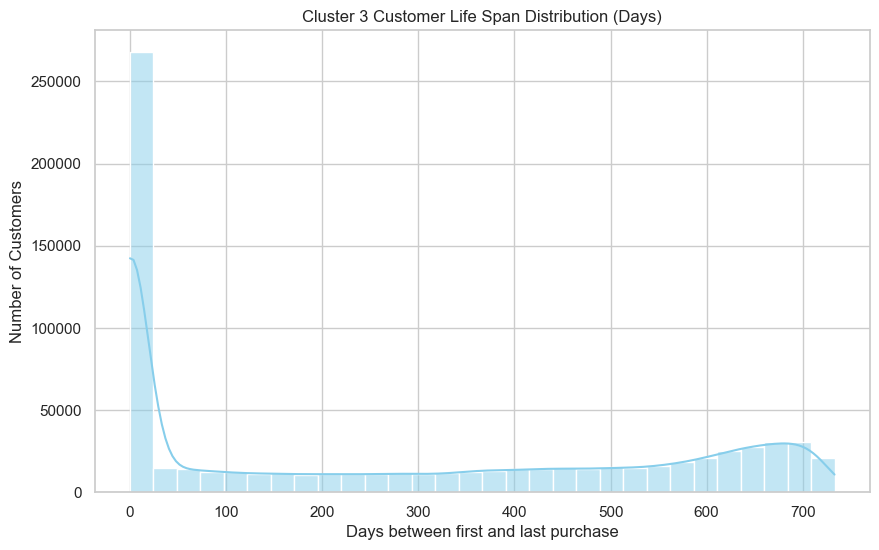

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cluster 3 데이터만 추출 (날짜 데이터를 날짜형식으로 변환)
c3_df = df_final[df_final['cluster'] == 3].copy()
c3_df['t_dat'] = pd.to_datetime(c3_df['t_dat'])

# 2. 고객별 LTV 관련 지표 계산
# 고객별로 [첫 구매일, 마지막 구매일, 총 구매금액, 총 구매횟수]를 구합니다.
ltv_base = c3_df.groupby('customer_id').agg({
    't_dat': ['min', 'max', 'count'],
    'price': 'sum'
}).reset_index()

# 컬럼 이름 정리
ltv_base.columns = ['customer_id', 'first_purchase', 'last_purchase', 'frequency', 'total_monetary']

# 3. 고객별 활동 기간(Life Span) 계산 (단위: 일)
ltv_base['life_span_days'] = (ltv_base['last_purchase'] - ltv_base['first_purchase']).dt.days

# 4. 활동 기간이 0일인 고객(단발성 구매)을 위해 최소 1일로 보정 후 일일 평균 매출 계산
ltv_base['daily_value'] = ltv_base['total_monetary'] / (ltv_base['life_span_days'] + 1)

# 5. Cluster 3 전체의 평균 지표 출력
print(f"--- Cluster 3 LTV 핵심 지표 ---")
print(f"평균 총 구매액(M): {ltv_base['total_monetary'].mean():.4f}")
print(f"평균 활동 기간: {ltv_base['life_span_days'].mean():.1f}일")
print(f"평균 구매 빈도(F): {ltv_base['frequency'].mean():.1f}회")
print(f"일일 기대 가치: {ltv_base['daily_value'].mean():.6f}")

# 6. 시각화 (활동 기간 분포)
plt.figure(figsize=(10, 6))
sns.histplot(ltv_base['life_span_days'], bins=30, kde=True, color='skyblue')
plt.title('Cluster 3 Customer Life Span Distribution (Days)')
plt.xlabel('Days between first and last purchase')
plt.ylabel('Number of Customers')
plt.show()